# Mask regular data with geometry data

This example masks ERA5 data (regular lat/lon grid) with country boundaries taken from the NUTS inventory. 

In [1]:
from earthkit import data as ekd
from earthkit import geo as ekg
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

In [2]:
remote_era5_file = earthkit_remote_test_data_file("era5_temperature_europe_20150101.grib")
era5_data = ekd.from_source("url", remote_era5_file)

geometry_data = ekg.gisco.nuts_regions(level=0).to_geopandas()
geometry_data.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,BA,0,BA,Bosna I Hercegovina,Bosna I Hercegovina,0.0,NaN,NaN,Bosnia and Herzegovina,Bosnie-et-Herzégovine,BIH,UN Member State,Sarajevo,F,F,T,Bosnien und Herzegowina,"MULTIPOLYGON (((16.92382 45.26542, 17.14119 45..."
1,BE,0,BE,Belgique/België,Belgique/België,NaN,NaN,NaN,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"POLYGON ((4.82637 51.48207, 4.84186 51.42493, ..."
2,BG,0,BG,Bulgaria,България,NaN,NaN,NaN,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"POLYGON ((22.88233 43.83546, 22.99717 43.80787..."
3,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,NaN,NaN,NaN,Switzerland,Suisse,CHE,UN Member State,Bern,F,T,F,Schweiz,"POLYGON ((8.70462 47.75557, 8.72798 47.69268, ..."
4,CY,0,CY,Kýpros,Κύπρος,NaN,NaN,NaN,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"POLYGON ((32.25443 35.06555, 32.42709 35.08197..."


In [3]:
# Mask ERA5 data with geometry
masked = ekt.spatial.mask(
    era5_data, geometry_data, mask_dim="NAME_ENGL", lat_key="latitude", lon_key="longitude"
)
masked


<xarray.Dataset> Size: 423MB
Dimensions:                  (NAME_ENGL: 39, forecast_reference_time: 24,
                              latitude: 201, longitude: 281)
Coordinates:
  * NAME_ENGL                (NAME_ENGL) object 312B 'Bosnia and Herzegovina'...
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 192B 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
Data variables:
    2t                       (NAME_ENGL, forecast_reference_time, latitude, longitude) float64 423MB dask.array<chunksize=(1, 24, 201, 281), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

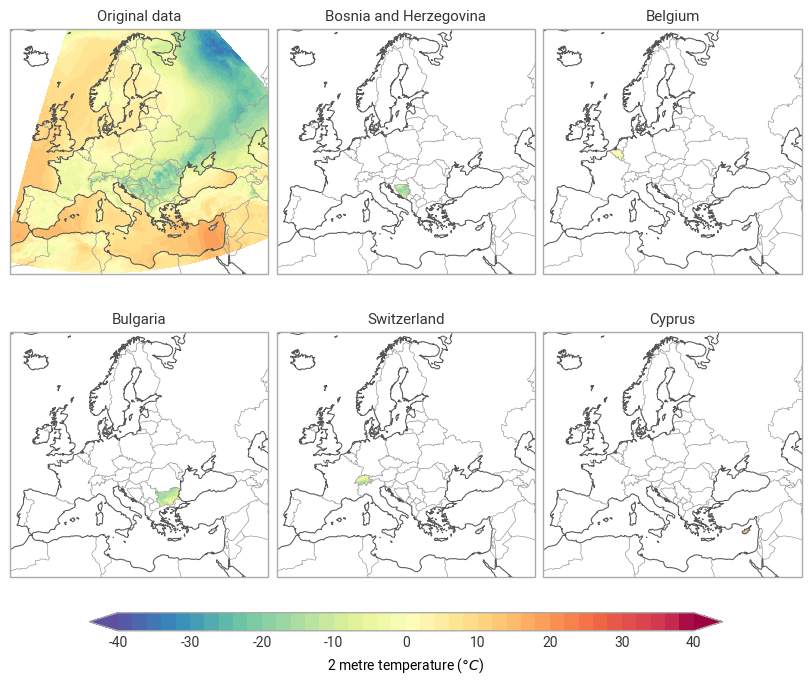

In [ ]:
plot_data = masked.isel(forecast_reference_time=0)
figure = ekp.Figure(domain="Europe", rows=2, columns=3)
nmaps = figure.rows * figure.columns

subplot = figure.add_map()
subplot.pcolormesh(era5_data, style="2m-temperature-spectral-celsius")
subplot.title("Original data")

for i in range(nmaps-1):
    subplot = figure.add_map()
    subplot.pcolormesh(plot_data.isel(NAME_ENGL=i), style="2m-temperature-spectral-celsius")
    subplot.title("{NAME_ENGL}")

figure.coastlines()
figure.borders()
figure.legend()
figure.show()